### Configuración GPU e Importaciones

In [1]:
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sysconfig import get_paths
import ctypes
import os
import gc
import pickle

site_packages = Path(get_paths()['purelib'])
cuda_lib_dirs = [
    site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
    site_packages / 'nvidia' / 'cuda_nvrtc' / 'lib',
    site_packages / 'nvidia' / 'cublas' / 'lib',
    site_packages / 'nvidia' / 'cufft' / 'lib',
    site_packages / 'nvidia' / 'curand' / 'lib',
    site_packages / 'nvidia' / 'cusolver' / 'lib',
    site_packages / 'nvidia' / 'cusparse' / 'lib',
    site_packages / 'nvidia' / 'cudnn' / 'lib',
    site_packages / 'nvidia' / 'cuda_cupti' / 'lib',
    site_packages / 'nvidia' / 'nccl' / 'lib',
    site_packages / 'nvidia' / 'nvjitlink' / 'lib',
]

loaded_cuda_libs = 0
for lib_dir in cuda_lib_dirs:
    if lib_dir.exists():
        for lib_path in sorted(lib_dir.glob('*.so*')):
            ctypes.CDLL(str(lib_path), mode=ctypes.RTLD_GLOBAL)
            loaded_cuda_libs += 1

existing_ld = os.environ.get('LD_LIBRARY_PATH', '')
cuda_ld_paths = [str(path) for path in cuda_lib_dirs if path.exists()]
if existing_ld:
    cuda_ld_paths.append(existing_ld)
os.environ['LD_LIBRARY_PATH'] = ':'.join(cuda_ld_paths)
print(f'Librerías CUDA cargadas: {loaded_cuda_libs}')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print('TensorFlow:', tf.__version__)
print('GPUs detectadas:', gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Crecimiento de memoria habilitado.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1783887274.295161  244326 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Librerías CUDA cargadas: 31
TensorFlow: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Crecimiento de memoria habilitado.


### Carga y Preprocesamiento de Datos

In [2]:
# Cargar dataset
print("Cargando dataset...")
df = pd.read_csv('../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Eliminar ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} características")

# Separar variables
X = df.drop('default', axis=1)
y = df['default']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Distribución clases - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

Cargando dataset...
Dataset cargado: 30000 registros, 24 características
Train: (24000, 23), Test: (6000, 23)
Distribución clases - Train: [18691  5309], Test: [4673 1327]


### Implementación de Grey Wolf Optimizer (GWO)

In [3]:
class GreyWolfOptimizerOptimized:
    """
    GWO Optimizado para mínimo consumo de memoria RAM
    """
    def __init__(self, n_wolves=15, max_iter=20, dim=4):
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.dim = dim
        # Historial para animaciones (AGREGAR ESTO)
        self.history_positions = []  # Posiciones de TODOS los lobos
        self.history_alpha = []      # Posición del mejor lobo (Alpha)
        self.history_fitness = []    # Fitness del Alpha
        
        # Inicializar posiciones con valores válidos
        self.positions = np.zeros((n_wolves, dim), dtype=np.float32)
        for i in range(n_wolves):
            self.positions[i, 0] = np.random.uniform(0.001, 0.01)    # learning_rate
            self.positions[i, 1] = np.random.uniform(0.1, 0.5)       # dropout_rate
            self.positions[i, 2] = np.random.uniform(16, 64)         # neurons1
            self.positions[i, 3] = np.random.uniform(8, 32)          # neurons2
        
        self.fitness = np.full(n_wolves, np.inf, dtype=np.float32)
        
        self.alpha_pos = np.zeros(dim, dtype=np.float32)
        self.alpha_score = np.inf
        self.beta_pos = np.zeros(dim, dtype=np.float32)
        self.beta_score = np.inf
        self.delta_pos = np.zeros(dim, dtype=np.float32)
        self.delta_score = np.inf
        
        self.history = []
        
    def create_mlp(self, params, input_dim):
        """Crear MLP con hiperparámetros dados"""
        lr = max(float(params[0]), 1e-6)
        dropout = np.clip(float(params[1]), 0.05, 0.7)
        n1 = max(int(params[2]), 8)
        n2 = max(int(params[3]), 4)
        
        model = Sequential([
            Dense(n1, activation='relu', input_dim=input_dim),
            BatchNormalization(),
            Dropout(dropout),
            Dense(n2, activation='relu'),
            BatchNormalization(),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        
        return model
    
    def evaluate_fitness(self, params, X_train, y_train, X_val, y_val):
        """
        Evaluar fitness con limpieza agresiva de memoria
        """
        model = None
        history = None
        fitness = np.inf
        
        try:
            # Crear modelo
            model = self.create_mlp(params, X_train.shape[1])
            
            # Entrenar con pocas épocas para evaluación rápida
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=8,  # Reducido para velocidad
                batch_size=256,
                verbose=0,
                callbacks=[
                    EarlyStopping(
                        monitor='val_auc', 
                        mode='max', 
                        patience=2, 
                        restore_best_weights=True
                    )
                ]
            )
            
            # Obtener AUC de validación
            if 'val_auc' in history.history and len(history.history['val_auc']) > 0:
                val_auc = max(history.history['val_auc'])
                
                if not np.isnan(val_auc) and not np.isinf(val_auc):
                    fitness = 1.0 - val_auc
            
        except Exception as e:
            print(f"Error en evaluación: {e}")
            fitness = np.inf
        
        finally:
            # LIMPIEZA AGRESIVA DE MEMORIA
            if model is not None:
                del model
            
            if history is not None:
                del history
            
            # Limpiar sesión de Keras (CRÍTICO)
            tf.keras.backend.clear_session()
            
            # Forzar garbage collection
            gc.collect()
        
        return fitness
    
    def optimize(self, X_train, y_train, X_val, y_val):
        """Ejecutar optimización guardando historial completo"""
        print(f"\n🐺 Iniciando GWO: {self.n_wolves} lobos, {self.max_iter} iteraciones")
        
        # Inicializar listas de historial
        self.history_positions = []
        self.history_alpha = []
        self.history_fitness = []
        
        # Evaluar población inicial
        print("Evaluando población inicial...")
        for i in range(self.n_wolves):
            self.fitness[i] = self.evaluate_fitness(
                self.positions[i], X_train, y_train, X_val, y_val
            )
            if i % 5 == 0:
                print(f"  Lobo {i+1}/{self.n_wolves}: fitness = {self.fitness[i]:.4f}")
        
        # Actualizar alpha, beta, delta iniciales
        sorted_indices = np.argsort(self.fitness)
        self.alpha_score = self.fitness[sorted_indices[0]]
        self.alpha_pos = self.positions[sorted_indices[0]].copy()
        self.beta_score = self.fitness[sorted_indices[1]]
        self.beta_pos = self.positions[sorted_indices[1]].copy()
        self.delta_score = self.fitness[sorted_indices[2]]
        self.delta_pos = self.positions[sorted_indices[2]].copy()
        
        # GUARDAR ESTADO INICIAL
        self.history_positions.append(self.positions.copy())
        self.history_alpha.append(self.alpha_pos.copy())
        self.history_fitness.append(self.alpha_score)
        
        print(f"\nMejor fitness inicial: {self.alpha_score:.4f} (AUC: {1-self.alpha_score:.4f})")
        
        # Loop principal
        for iteration in range(self.max_iter):
            a = 2 * (1 - (iteration / self.max_iter) ** 2)
            
            # Actualizar posiciones
            for i in range(self.n_wolves):
                for j in range(self.dim):
                    r1, r2 = np.random.random(), np.random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta
                    
                    self.positions[i, j] = (X1 + X2 + X3) / 3
            
            # Mantener límites
            self.positions[:, 0] = np.clip(self.positions[:, 0], 0.0001, 0.01)
            self.positions[:, 1] = np.clip(self.positions[:, 1], 0.05, 0.7)
            self.positions[:, 2] = np.clip(self.positions[:, 2], 8, 128)
            self.positions[:, 3] = np.clip(self.positions[:, 3], 4, 64)
            
            # Evaluar nueva población
            for i in range(self.n_wolves):
                self.fitness[i] = self.evaluate_fitness(
                    self.positions[i], X_train, y_train, X_val, y_val
                )
            
            # Actualizar alpha, beta, delta
            for i in range(self.n_wolves):
                if self.fitness[i] < self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.alpha_score
                    self.beta_pos = self.alpha_pos.copy()
                    self.alpha_score = self.fitness[i]
                    self.alpha_pos = self.positions[i].copy()
                elif self.fitness[i] < self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta_pos = self.beta_pos.copy()
                    self.beta_score = self.fitness[i]
                    self.beta_pos = self.positions[i].copy()
                elif self.fitness[i] < self.delta_score:
                    self.delta_score = self.fitness[i]
                    self.delta_pos = self.positions[i].copy()
            
            # GUARDAR HISTORIAL EN CADA ITERACIÓN
            self.history_positions.append(self.positions.copy())
            self.history_alpha.append(self.alpha_pos.copy())
            self.history_fitness.append(self.alpha_score)
            
            if iteration % 5 == 0:
                print(f"Iter {iteration:3d} | Alpha AUC: {1-self.alpha_score:.4f} | "
                      f"LR: {self.alpha_pos[0]:.5f}, DO: {self.alpha_pos[1]:.3f}, "
                      f"N1: {int(self.alpha_pos[2])}, N2: {int(self.alpha_pos[3])}")
            
            gc.collect()
        
        # Verificar resultado final
        if np.isinf(self.alpha_score):
            print("\nADVERTENCIA: No se encontró solución válida.")
            self.alpha_pos = np.array([0.001, 0.2, 32, 16], dtype=np.float32)
            self.alpha_score = 0.3
        
        print(f"\nOptimización completada!")
        print(f"Mejor AUC: {1-self.alpha_score:.4f}")
        print(f"Mejor configuración: LR={self.alpha_pos[0]:.5f}, Dropout={self.alpha_pos[1]:.3f}, "
              f"N1={int(self.alpha_pos[2])}, N2={int(self.alpha_pos[3])}\n")
        
        return self.alpha_pos, self.alpha_score
    
    def save(self, filepath='gwo_state.pkl'):
        """
        Guarda el estado completo del GWO en un archivo pickle
        """
        state = {
            'n_wolves': self.n_wolves,
            'max_iter': self.max_iter,
            'dim': self.dim,
            'positions': self.positions,
            'fitness': self.fitness,
            'alpha_pos': self.alpha_pos,
            'alpha_score': self.alpha_score,
            'beta_pos': self.beta_pos,
            'beta_score': self.beta_score,
            'delta_pos': self.delta_pos,
            'delta_score': self.delta_score,
            'history_positions': self.history_positions,
            'history_alpha': self.history_alpha,
            'history_fitness': self.history_fitness,
            'history': self.history,
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(state, f)
        
        print(f"Estado del GWO guardado en: {filepath}")
        print(f"   Tamaño del archivo: {os.path.getsize(filepath) / 1024:.2f} KB")
    
    def load(self, filepath='gwo_state.pkl'):
        """
        Carga el estado completo del GWO desde un archivo pickle
        """
        if not os.path.exists(filepath):
            print(f"No existe el archivo: {filepath}")
            return False
        
        with open(filepath, 'rb') as f:
            state = pickle.load(f)
        
        # Restaurar todos los atributos
        self.n_wolves = state['n_wolves']
        self.max_iter = state['max_iter']
        self.dim = state['dim']
        self.positions = state['positions']
        self.fitness = state['fitness']
        self.alpha_pos = state['alpha_pos']
        self.alpha_score = state['alpha_score']
        self.beta_pos = state['beta_pos']
        self.beta_score = state['beta_score']
        self.delta_pos = state['delta_pos']
        self.delta_score = state['delta_score']
        self.history_positions = state['history_positions']
        self.history_alpha = state['history_alpha']
        self.history_fitness = state['history_fitness']
        self.history = state['history']
        
        print(f"Estado del GWO cargado desde: {filepath}")
        print(f"   Mejor AUC encontrado: {1 - self.alpha_score:.4f}")
        print(f"   Iteraciones realizadas: {len(self.history_fitness)}")
        return True

#### Funcion para crear las animaciones 3d

In [4]:
def create_gwo_animation_3d_with_surface(gwo, save_path='gwo_animacion_3d_superficie'):
    """
    Crea animación 3D del GWO con superficie y puntos visibles
    """
    
    if not hasattr(gwo, 'history_positions') or len(gwo.history_positions) == 0:
        print("No hay historial de posiciones.")
        return None
    
    history_positions = np.array(gwo.history_positions)
    history_alpha = np.array(gwo.history_alpha)
    history_fitness = np.array(gwo.history_fitness)
    
    n_iterations = len(history_fitness)
    n_wolves = gwo.n_wolves
    
    print(f"Creando animación 3D con superficie... {n_iterations} iteraciones, {n_wolves} lobos")
    
    # =====================================================
    # FUNCIÓN DE FITNESS
    # =====================================================
    def fitness_function(x, y):
        x_norm = (x - 0.001) / (0.01 - 0.001) * 10 - 5
        y_norm = (y - 0.05) / (0.7 - 0.05) * 10 - 5
        
        A = 10
        fitness = A * 2 + (x_norm**2 - A * np.cos(2 * np.pi * x_norm)) + \
                  (y_norm**2 - A * np.cos(2 * np.pi * y_norm))
        fitness -= 20 * np.exp(-0.2 * ((x_norm - 2)**2 + (y_norm - 1)**2))
        
        return fitness
    
    x_range = np.linspace(0.001, 0.01, 50)
    y_range = np.linspace(0.05, 0.7, 50)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = fitness_function(X_mesh, Y_mesh)
    
    # =====================================================
    # CREAR FIGURA
    # =====================================================
    fig = plt.figure(figsize=(12, 12))
    
    def update(frame):
        fig.clear()
        ax = fig.add_subplot(111, projection='3d')
        
        # 1️⃣ PRIMERO: Superficie con alpha BAJO (0.3) y SIN aristas
        surf = ax.plot_surface(X_mesh, Y_mesh, Z_mesh, 
                              cmap='coolwarm', 
                              alpha=0.3,          
                              edgecolor='none',  
                              antialiased=True,
                              zorder=1,
                              shade=True)            
        
        # 2️⃣ SEGUNDO: Lobos con zorder ALTO
        wolf_pos = history_positions[frame]
        alpha_pos = history_alpha[frame]
        
        wolf_z = fitness_function(wolf_pos[:, 0], wolf_pos[:, 1])
        alpha_z = fitness_function(alpha_pos[0], alpha_pos[1])
        
        # 🔑 Lobos: tamaño grande, zorder alto, depthshade=False
        ax.scatter(wolf_pos[:, 0], wolf_pos[:, 1], wolf_z, 
                  c='yellow', 
                  s=200,                   
                  label='Lobos', 
                  edgecolors='black', 
                  linewidth=2, 
                  alpha=1.0,               
                  zorder=10,               
                  depthshade=False)       
        
        # 🔑 Alpha: aún más grande y destacado
        ax.scatter([alpha_pos[0]], [alpha_pos[1]], [alpha_z], 
                  c='blue', 
                  s=500,                 
                  marker='X', 
                  label='Alpha (Mejor)', 
                  zorder=11,            
                  edgecolors='black', 
                  linewidth=2,
                  depthshade=False)       
        
        # 3️ TERCERO: Líneas de conexión (zorder medio)
        for i in range(n_wolves):
            ax.plot([wolf_pos[i, 0], alpha_pos[0]],
                   [wolf_pos[i, 1], alpha_pos[1]],
                   [wolf_z[i], alpha_z], 
                   'g--', alpha=0.6, linewidth=1.5, zorder=5)
        
        # Información
        fitness = history_fitness[frame]
        auc = 1 - fitness
        ax.text2D(0.02, 0.98, f'Iteración: {frame}/{n_iterations-1}\n'
                    f'Fitness: {fitness:.4f}\n'
                    f'AUC: {auc:.4f}\n'
                    f'LR: {alpha_pos[0]:.5f}\n'
                    f'Dropout: {alpha_pos[1]:.3f}', 
                 transform=ax.transAxes, fontsize=11,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                 zorder=20)
        
        ax.set_xlabel('Learning Rate', fontsize=12, labelpad=10)
        ax.set_ylabel('Dropout', fontsize=12, labelpad=10)
        ax.set_zlabel('Fitness (menor es mejor)', fontsize=12, labelpad=10)
        ax.set_title(f'GWO - Iteración {frame}', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right', fontsize=12)
        
        ax.set_xlim(0.001, 0.01)
        ax.set_ylim(0.05, 0.7)
        ax.set_zlim(Z_mesh.min(), Z_mesh.max())
        
        # Rotación suave
        ax.view_init(elev=10+frame*2, azim=20+frame*4)
    
    # =====================================================
    # CREAR Y GUARDAR
    # =====================================================
    print("Generando animación...")
    anim = FuncAnimation(fig, update, frames=n_iterations, 
                        interval=800, repeat=True)
    
    try:
        anim.save(f'{save_path}.gif', writer=PillowWriter(fps=5), dpi=150)
        print(f"Animación guardada en: {save_path}.gif")
        return anim
    except Exception as e:
        print(f"Error al guardar: {e}")
        import traceback
        traceback.print_exc()
        return None

#### Funcion para guardar el modelo GWO

In [5]:
def get_gwo_result(filepath='gwo_state.pkl', n_wolves=15, max_iter=20, dim=4,
                   X_train=None, y_train=None, X_val=None, y_val=None,
                   force_retrain=False):
    """
    Carga el GWO desde archivo si existe, o lo ejecuta y guarda.
    
    Parámetros:
    -----------
    filepath : str - Ruta del archivo de estado
    force_retrain : bool - Si True, ignora el archivo y re-entrena
    """
    gwo = GreyWolfOptimizerOptimized(
        n_wolves=n_wolves,
        max_iter=max_iter,
        dim=dim
    )
    
    # Intentar cargar estado guardado
    if not force_retrain and os.path.exists(filepath):
        print(f"Encontrado estado guardado: {filepath}")
        print(f"Cargando estado en lugar de re-entrenar...\n")
        gwo.load(filepath)
        return gwo.alpha_pos, gwo.alpha_score, gwo
    
    # Si no existe o force_retrain=True, ejecutar
    print(f"No hay estado guardado (o force_retrain=True). Ejecutando GWO...")
    best_params, best_fitness = gwo.optimize(X_train, y_train, X_val, y_val)
    
    # Guardar el estado para futuras ejecuciones
    gwo.save(filepath)
    
    return best_params, best_fitness, gwo

### Ejecutar Optimización GWO

In [6]:
# =====================================================
# CONFIGURACIÓN
# =====================================================
GWO_STATE_FILE = 'gwo_state.pkl'  # Nombre del archivo de estado
FORCE_RETRAIN = False              # True si quieres re-entrenar

# Dividir datos para GWO
X_train_gwo, X_val, y_train_gwo, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convertir a float32
X_train_gwo = X_train_gwo.astype(np.float32)
X_val = X_val.astype(np.float32)
y_train_gwo = y_train_gwo.astype(np.float32)
y_val = y_val.astype(np.float32)

print("🐺 Iniciando optimización GWO con guardado de historial...")

# Inicializar GWO
best_params, best_fitness, gwo = get_gwo_result(
    filepath=GWO_STATE_FILE,
    n_wolves=15,
    max_iter=20,
    dim=4,
    X_train=X_train_gwo,
    y_train=y_train_gwo,
    X_val=X_val,
    y_val=y_val,
    force_retrain=FORCE_RETRAIN  # ⚠️ Cambia esto a True para re-entrenar
)

# Extraer parámetros
best_lr = float(best_params[0])
best_dropout = float(best_params[1])
best_n1 = int(best_params[2])
best_n2 = int(best_params[3])

print(f"\nGWO completado!")
print(f"Mejores parámetros: LR={best_lr}, Dropout={best_dropout}, N1={best_n1}, N2={best_n2}")


🐺 Iniciando optimización GWO con guardado de historial...
Encontrado estado guardado: gwo_state.pkl
Cargando estado en lugar de re-entrenar...

Estado del GWO cargado desde: gwo_state.pkl
   Mejor AUC encontrado: 0.7759
   Iteraciones realizadas: 21

GWO completado!
Mejores parámetros: LR=0.0054058413952589035, Dropout=0.23497648537158966, N1=114, N2=27


#### Generar animaciones

In [ ]:
anim_3d = create_gwo_animation_3d_with_surface(gwo, save_path='gwo_animacion_3d')
display(Image(filename='gwo_animacion_3d.gif'))

### Entrenar Modelo Final con Mejores Parámetros

In [8]:
# Crear modelo final con mejores hiperparámetros
print("\n🚀 Entrenando modelo final con hiperparámetros optimizados...")

final_model = Sequential([
    Dense(best_n1, activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(best_n2, activation='relu'),
    BatchNormalization(),
    Dropout(best_dropout),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_lr),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Calcular class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Entrenar
history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nModelo final entrenado exitosamente!")


🚀 Entrenando modelo final con hiperparámetros optimizados...


I0000 00:00:1783887314.403411  244326 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/500


I0000 00:00:1783887317.302152  245080 service.cc:153] XLA service 0x7fec50034d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783887317.302171  245080 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783887317.360209  245080 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783887317.712057  245080 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783887317.793170  245080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2525__.25


59/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6895 - auc: 0.7185 - loss: 0.6370

I0000 00:00:1783887322.100913  245080 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6924 - auc: 0.7214 - loss: 0.6288 - val_accuracy: 0.7038 - val_auc: 0.7561 - val_loss: 0.6326 - learning_rate: 0.0054
Epoch 2/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7466 - auc: 0.7616 - loss: 0.5777 - val_accuracy: 0.7240 - val_auc: 0.7695 - val_loss: 0.6053 - learning_rate: 0.0054
Epoch 3/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7420 - auc: 0.7686 - loss: 0.5714 - val_accuracy: 0.7456 - val_auc: 0.7696 - val_loss: 0.5885 - learning_rate: 0.0054
Epoch 4/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7491 - auc: 0.7729 - loss: 0.5658 - val_accuracy: 0.7385 - val_auc: 0.7744 - val_loss: 0.5841 - learning_rate: 0.0054
Epoch 5/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7468 - auc: 0.7764 - loss: 0.5629 - val_accuracy: 0.7165 - val_auc: 0.7710 - val_loss: 0.5824 - learning_rate: 0.0054
Epoch 6/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7417 - auc: 0.7771 - loss: 0.5

### Evaluación y Métricas


EVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy:  0.7410
Precision: 0.4390
Recall:    0.6157
F1-Score:  0.5125
ROC-AUC:   0.7676


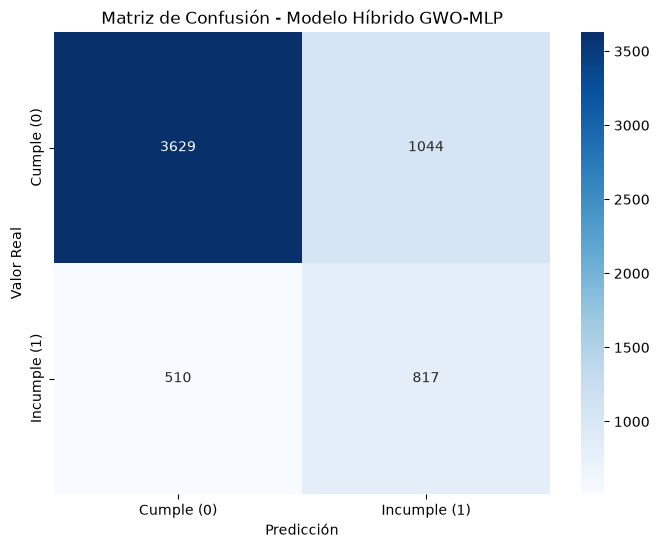


TP: 817 | FP: 1044
FN: 510 | TN: 3629


In [9]:
# Evaluar en test set
print("\nEVALUACIÓN DEL MODELO HÍBRIDO GWO-MLP")
print("="*60)

y_pred_prob = final_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*60)

# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cumple (0)', 'Incumple (1)'],
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title('Matriz de Confusión - Modelo Híbrido GWO-MLP')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

print(f"\nTP: {cm[1,1]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]} | TN: {cm[0,0]}")

### Visualización de Convergencia GWO

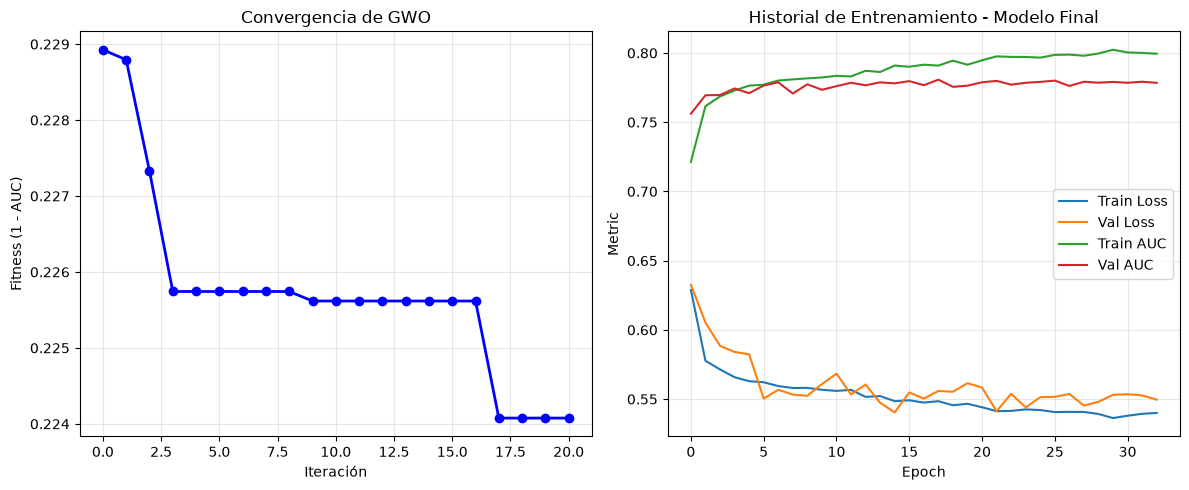

In [10]:
# Visualizar convergencia de GWO
if not hasattr(gwo, 'history_fitness') or len(gwo.history_fitness) == 0:
    print('No hay historial de convergencia para mostrar.')
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    iterations = np.arange(len(gwo.history_fitness))
    scores = gwo.history_fitness
    plt.plot(iterations, scores, 'b-o', linewidth=2, markersize=6)
    plt.xlabel('Iteración')
    plt.ylabel('Fitness (1 - AUC)')
    plt.title('Convergencia de GWO')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Val AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title('Historial de Entrenamiento - Modelo Final')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()